# Unveiling the Carbon Paradox: A Data-Driven Analysis of Global Energy Profiles
**Team Project - Programming for Data Science - Group 4**

## 1. Introduction & Business Understanding
This project investigates the complex relationship between renewable energy adoption and carbon emissions. We hypothesize the existence of a "Carbon Paradox": merely transitioning to a green grid (high renewable share) does not guarantee low per capita carbon emissions if absolute energy consumption (energy intensity) remains high.

## 2. Data Preparation
We integrate six datasets from Our World in Data (OWID) and the World Bank, merging them into a comprehensive panel dataset (2000-2022).

In [2]:
# Import core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# ==========================================
# Step 1: Load the 6 downloaded CSV files
# ==========================================
df_energy_intensity = pd.read_csv('dataset/energy-intensity.csv')
df_carbon_intensity = pd.read_csv('dataset/co2-intensity.csv')
df_co2_per_capita = pd.read_csv('dataset/co-emissions-per-capita.csv')
df_primary_renewable_share = pd.read_csv('dataset/renewable-share-energy.csv')
df_electricity_access = pd.read_csv('dataset/share-of-the-population-with-access-to-electricity.csv')
df_elec_renewable_share = pd.read_csv('dataset/share-electricity-renewables.csv') 

# ==========================================
# Step 2: Sequential Outer Join to create the master dataset
# ==========================================
dataframes = [
    df_energy_intensity, df_carbon_intensity, df_co2_per_capita, 
    df_primary_renewable_share, df_electricity_access, df_elec_renewable_share
]
merge_keys = ['Entity', 'Code', 'Year']

df_merged = dataframes[0]
for df in dataframes[1:]:
    df_merged = pd.merge(df_merged, df, on=merge_keys, how='outer')

# ==========================================
# Step 3: Filter years and clean non-country entities
# ==========================================
# We focus on the modern energy transition era (2000-2022)
df_final = df_merged[(df_merged['Year'] >= 2000) & (df_merged['Year'] <= 2022)]

# Drop regional aggregates (e.g., "World", "Asia") that lack a 3-letter country code
df_final = df_final.dropna(subset=['Code'])

# ==========================================
# Step 4: Standardize Column Names for Code Readability
# ==========================================
df_historical = df_final.rename(columns={
    'Energy consumption per dollar': 'Energy_Intensity',
    'Annual CO₂ emissions per GDP (kg per international-$)': 'CO2_Intensity',
    'CO₂ emissions per capita': 'CO2_Per_Capita',
    'Renewables_x': 'Renewable_Primary_Share',
    'Share of the population with access to electricity': 'Electricity_Access',
    'Renewables_y': 'Renewable_Elec_Share'
})

print("Data Loading & Merging Complete!")
print(f"Total historical records available: {len(df_historical)} rows.")

Data Loading & Merging Complete!
Total historical records available: 5760 rows.


## 3. Data Cleaning & Feature Selection
While the historical dataset is essential for time-series tracking, K-Means clustering requires a cross-sectional snapshot to compare nations accurately. We selected the year **2021** as it represents the most complete recent dataset prior to the 2022 global energy crisis. 

During missing value diagnosis, we observed massive global gaps in the `Renewable_Primary_Share` metric. To prevent the exclusion of developing nations from our analysis, we strategically dropped this feature and focused on electricity generation and energy intensity metrics.

In [3]:
# ==========================================
# Step 1: Extract the 2021 cross-section
# ==========================================
df_2021 = df_historical[df_historical['Year'] == 2021].copy()

# ==========================================
# Step 2: Define Core Features & Handle Missing Data
# ==========================================
core_features = [
    'Energy_Intensity', 
    'CO2_Intensity', 
    'CO2_Per_Capita', 
    'Electricity_Access', 
    'Renewable_Elec_Share'
]

# Drop rows that are missing our core analytical features
df_clustering_2021 = df_2021.dropna(subset=core_features).copy()

print("Data Slicing Complete!")
print(f"Final number of countries ready for 2021 modeling: {len(df_clustering_2021)}")
# This should output 164 countries

Data Slicing Complete!
Final number of countries ready for 2021 modeling: 164


## 4.1 Exploratory Data Analysis (EDA)
Before applying machine learning algorithms, we conducted EDA to visually inspect the relationships between our key variables. The correlation heatmap and scatter plots immediately reveal the non-linear, paradoxical relationship between green electricity and overall carbon emissions.

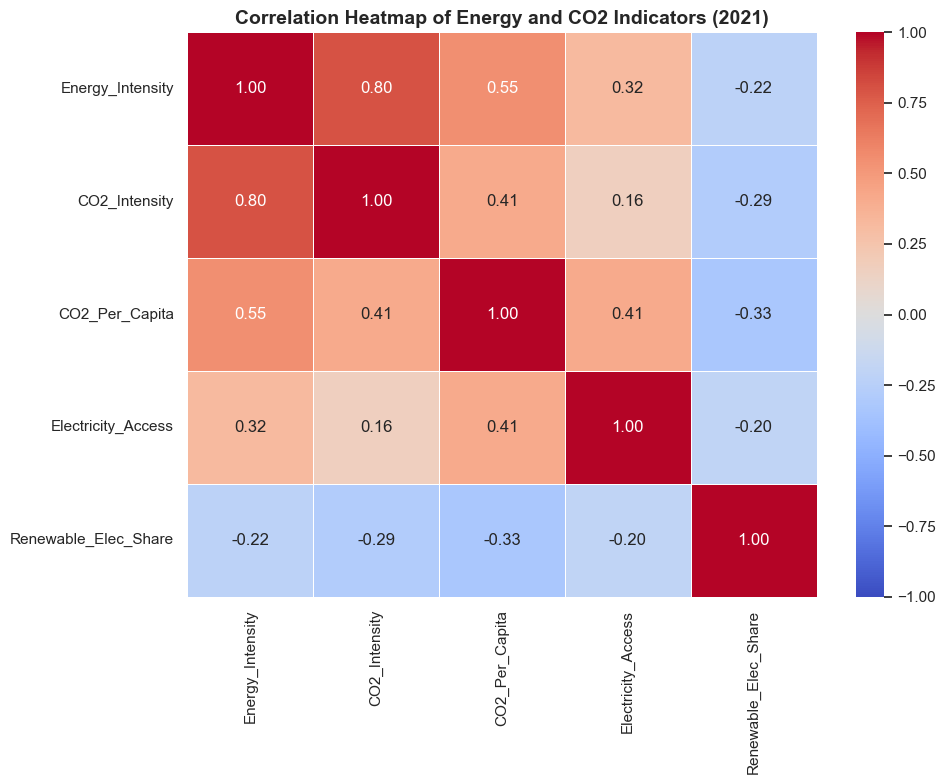

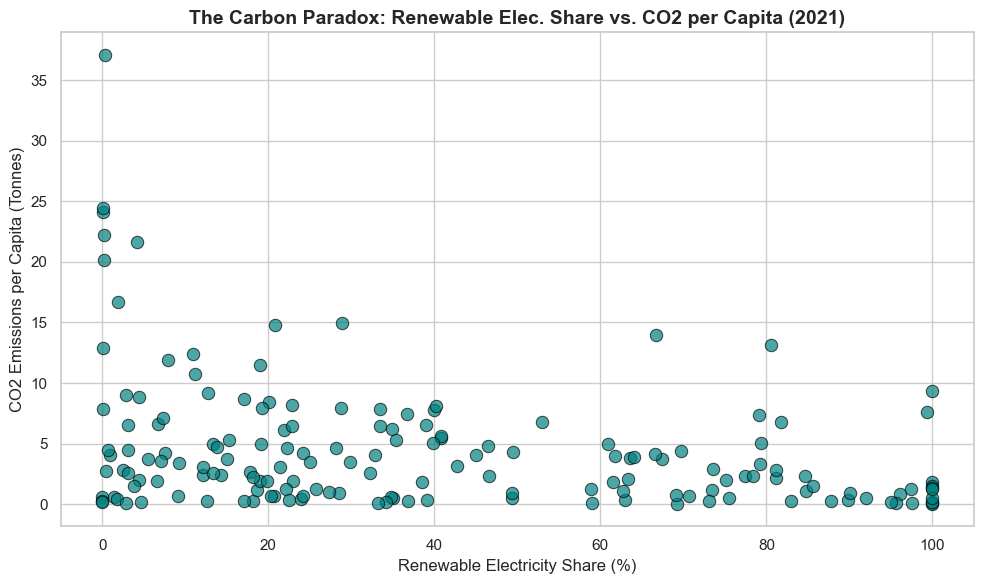

In [4]:
# ==========================================
# Exploratory Visualizations
# ==========================================
sns.set_theme(style="whitegrid")

# Plot 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_clustering_2021[core_features].corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Energy and CO2 Indicators (2021)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Scatter Plot mapping the Carbon Paradox
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clustering_2021, 
    x='Renewable_Elec_Share', 
    y='CO2_Per_Capita', 
    alpha=0.7, 
    s=80, 
    color='teal', 
    edgecolor='black'
)
plt.title('The Carbon Paradox: Renewable Elec. Share vs. CO2 per Capita (2021)', fontsize=14, fontweight='bold')
plt.xlabel('Renewable Electricity Share (%)', fontsize=12)
plt.ylabel('CO2 Emissions per Capita (Tonnes)', fontsize=12)
plt.tight_layout()
plt.show()

## 4.2 Multivariate Visualization: 4D Interactive Bubble Chart

To explore the multivariate relationships underlying the Carbon Paradox prior to formal formal modeling, an interactive four-dimensional bubble chart is constructed using Plotly. This visualization supersedes traditional two-dimensional scatter plots by simultaneously mapping renewable electricity share (x-axis), CO2 emissions per capita (y-axis), energy intensity (bubble size), and categorical cluster assignments (color). This methodology allows for an intuitive, granular inspection of individual country profiles through hover interactions, ensuring that complex non-linear dynamics are visually parsed before applying algorithmic classification.

In [13]:
import plotly.express as px

# Create an interactive 4D Bubble Chart for EDA
fig_bubble = px.scatter(
    df_clustering_2021,
    x='Renewable_Elec_Share',
    y='CO2_Per_Capita',
    size='Energy_Intensity',
    color='Cluster_Name',
    hover_name='Entity',
    color_discrete_map={
        'Energy-Hungry Giants (Cluster 0)': '#e41a1c',
        'The Forced Green (Cluster 1)': '#4daf4a',
        'Transitioning Majority (Cluster 2)': '#377eb8'
    },
    size_max=40,
    opacity=0.7,
    title="Multivariate EDA: The Carbon Paradox in 4 Dimensions (2021)",
    labels={
        'Renewable_Elec_Share': 'Renewable Electricity Share (%)',
        'CO2_Per_Capita': 'CO2 Emissions per Capita (Tonnes)'
    }
)

fig_bubble.update_layout(
    title=dict(font=dict(size=18), x=0.5),
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray'),
    plot_bgcolor='white',
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig_bubble.show()

## 5.1 Unsupervised Learning (Clustering)
K-Means clustering relies on Euclidean distance; therefore, we must first standardize our diverse metrics (e.g., percentages vs. per capita tonnes) using `StandardScaler` to ensure equal weighting. 

Selecting the right number of clusters is critical for the interpretability of our model. We employed two industry-standard techniques to find the "Sweet Spot" for $K$:

### a). The Elbow Method (Inertia Analysis)
We first plotted the **Within-Cluster Sum of Squares (Inertia)** for $K$ values ranging from 1 to 10. 
* **Observation:** In our dataset, the Elbow Curve appeared relatively smooth without a sharp, distinct "elbow" point (the point where the rate of decrease significantly flattens). 
* **Conclusion:** Because the visual evidence from the Elbow Method was ambiguous, we required a more mathematically robust metric to justify our selection.

### b). The Silhouette Coefficient Analysis
Next, we calculated the **Silhouette Score** for $K=2$ through $K=10$. This metric measures how similar an object is to its own cluster compared to other clusters (ranging from -1 to +1).
* **Observation:** The Silhouette Score peaked at **$K=3$**, indicating that this configuration provides the best separation and cohesion for the global energy data. 
* **Business Logic:** A choice of **$K=3$** also aligns perfectly with our research objective, as it allows us to categorize nations into three distinct developmental archetypes: the energy-intensive giants, the green-but-impoverished nations, and the transitioning majority.

### Final Decision: $K=3$
Based on the superior Silhouette Score and the clear interpretability of the resulting country profiles, we proceeded with **K=3** for the final model execution.

To validate and visualize this multi-dimensional clustering, we applied **Principal Component Analysis (PCA)** to project the 5D feature space into a 2D scatter plot.

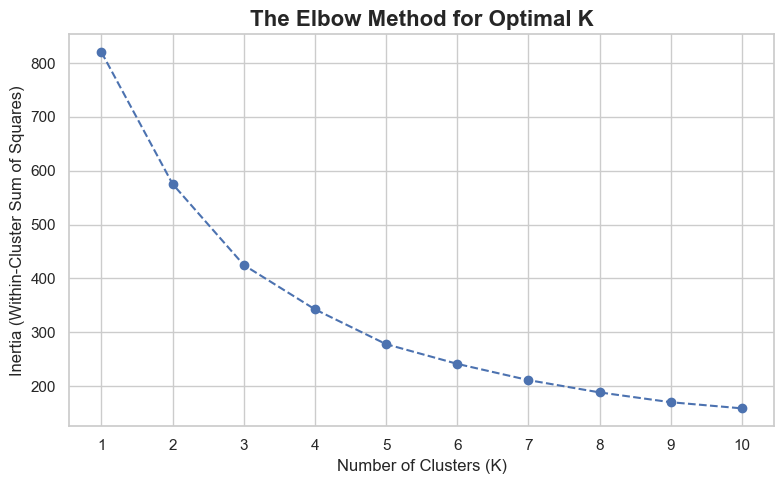

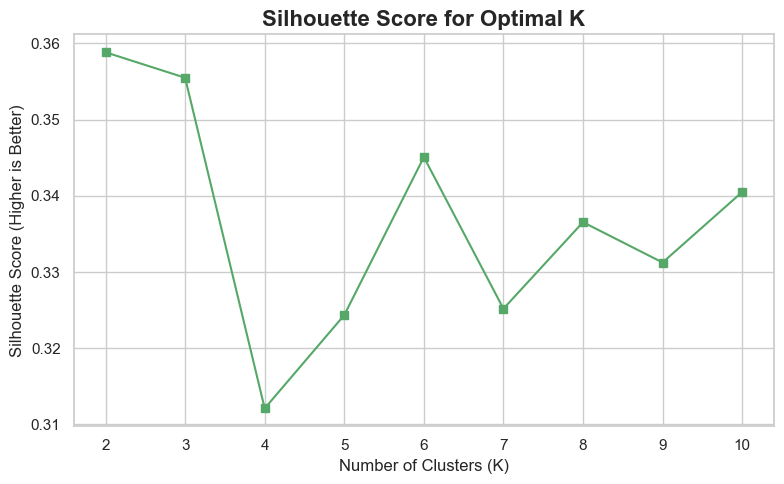

For K=2, Silhouette Score: 0.3588
For K=3, Silhouette Score: 0.3555
For K=4, Silhouette Score: 0.3121
For K=5, Silhouette Score: 0.3243
For K=6, Silhouette Score: 0.3451
For K=7, Silhouette Score: 0.3252
For K=8, Silhouette Score: 0.3365
For K=9, Silhouette Score: 0.3312
For K=10, Silhouette Score: 0.3405
AVERAGE PROFILES FOR EACH COUNTRY CLUSTER (K=3):
Cluster_Label             0      1       2
Energy_Intensity       2.70   0.64    1.08
CO2_Intensity          0.58   0.17    0.22
CO2_Per_Capita        13.64   0.42    4.16
Electricity_Access    95.04  45.33   97.83
Renewable_Elec_Share  19.35  53.14   38.82
Number_of_Countries   20.00  37.00  107.00

Sample countries in Cluster 0:
['Bahrain', 'Canada', 'Iceland']

Sample countries in Cluster 1:
['Angola', 'Benin', 'Burkina Faso']

Sample countries in Cluster 2:
['Afghanistan', 'Albania', 'Algeria']


In [5]:
#Clustering Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define the features to be used for clustering
clustering_features = [
    'Energy_Intensity',
    'CO2_Intensity',
    'CO2_Per_Capita',
    'Electricity_Access',
    'Renewable_Elec_Share'
]

# Extract the data for the model
X = df_clustering_2021[clustering_features]

# ==========================================
# Step 1: Data Standardization (Crucial!)
# ==========================================
# K-Means is a distance-based algorithm. We must scale the data so that
# variables like percentages (0-100) and per capita emissions (small numbers)
# do not disproportionately influence the distance calculations.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# Step 2: The Elbow Method
# ==========================================
# We will test K (number of clusters) from 1 to 10 and record the inertia.
# Inertia measures how well a dataset was clustered (lower is better, but it decreases as K increases).
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    # Set random_state for reproducibility
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# ==========================================
# Step 3: Plot the Elbow Curve
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.metrics import silhouette_score

# We need to test K from 2 to 10 (Silhouette score requires at least 2 clusters)
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    # Initialize and fit the KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Calculate the silhouette score for this K
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# ==========================================
# Plot the Silhouette Scores
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Silhouette Score for Optimal K', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score (Higher is Better)', fontsize=12)
plt.xticks(k_range_sil)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the scores explicitly to find the exact maximum
for i, k in enumerate(k_range_sil):
    print(f"For K={k}, Silhouette Score: {silhouette_scores[i]:.4f}")

# ==========================================
# Final K-Means Model Execution (K=3)
# ==========================================
# We choose K=3 based on the Silhouette scores and our business objective
# to identify the "Carbon Paradox" among different development stages.

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit the model and assign the cluster labels back to our actual dataframe
df_clustering_2021['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

# ==========================================
# Cluster Profiling (Evaluation Phase)
# ==========================================
# Calculate the average values for each indicator within each cluster
# This helps us define the "persona" or "profile" of each group

cluster_profiles = df_clustering_2021.groupby('Cluster_Label')[core_features].mean()

# Count how many countries are in each cluster
cluster_counts = df_clustering_2021['Cluster_Label'].value_counts().sort_index()
cluster_profiles['Number_of_Countries'] = cluster_counts

print("======================================================")
print("AVERAGE PROFILES FOR EACH COUNTRY CLUSTER (K=3):")
print("======================================================")
# Transpose the output to make it easier to read in the console
print(cluster_profiles.T.round(2))

# Optional: Print out a few sample countries from each cluster to verify
print("\nSample countries in Cluster 0:")
print(df_clustering_2021[df_clustering_2021['Cluster_Label'] == 0]['Entity'].head(3).tolist())

print("\nSample countries in Cluster 1:")
print(df_clustering_2021[df_clustering_2021['Cluster_Label'] == 1]['Entity'].head(3).tolist())

print("\nSample countries in Cluster 2:")
print(df_clustering_2021[df_clustering_2021['Cluster_Label'] == 2]['Entity'].head(3).tolist())

## 5.2 Feature Intersection Analysis: Parallel Coordinates Plot

To trace the specific multidimensional pathways of individual nations across the defined energy metrics, a Parallel Coordinates Plot is generated. While scatter plots are limited to evaluating variables in pairs or triads, parallel coordinates map multiple continuous variables simultaneously along parallel vertical axes. Each nation is represented as a connected polyline, with its color denoting its designated K-Means cluster. This visualization technique is deployed to identify structural intersections and trace how extreme values in one parameter (e.g., renewable share) correspond to divergent outcomes in target variables (e.g., carbon emissions), thereby exposing the underlying mechanics of the Carbon Paradox.

In [19]:
import plotly.express as px

# Create Parallel Coordinates Plot
# Note: Plotly's parallel_coordinates requires numeric color coding
fig_par = px.parallel_coordinates(
    df_clustering_2021,
    dimensions=['Renewable_Elec_Share', 'Electricity_Access', 'Energy_Intensity', 'CO2_Per_Capita'],
    color='Cluster_Label',
    color_continuous_scale=[(0.00, '#e41a1c'),   # Red for Cluster 0
                            (0.50, '#4daf4a'),   # Green for Cluster 1
                            (1.00, '#377eb8')],  # Blue for Cluster 2
    title="Parallel Coordinates: Feature Intersections of Energy Archetypes",
    labels={
        'Renewable_Elec_Share': 'Renewable Share',
        'Electricity_Access': 'Elec Access',
        'Energy_Intensity': 'Energy Intensity',
        'CO2_Per_Capita': 'CO2 Per Capita'
    }
)

fig_par.update_layout(
    title=dict(font=dict(size=18), x=0.5),
    coloraxis_colorbar=dict(
        title="Cluster",
        tickvals=[0, 1, 2],
        ticktext=['Cluster 0', 'Cluster 1', 'Cluster 2']
    ),
    margin=dict(l=75, r=75, t=100, b=50)
)

fig_par.show()

## 5.3 Geospatial Visualization: Mapping the Global Energy Landscape

To move beyond abstract data points, we project our clustering results onto an **interactive global choropleth map**. By leveraging the **ISO Alpha-3 country codes** (e.g., USA, CHN, CAN) present in our dataset, we utilize the `Plotly` library to visualize the geographical distribution of our three identified energy archetypes.

### Why use a Geospatial Map?
This interactive visualization serves as a powerful tool for macro-economic analysis:
* **Geographical Patterns:** It allows us to immediately identify regional trends, such as the concentration of "Energy-Hungry Giants" in specific industrial hubs or the "Forced Green" status across much of the Global South.
* **Data Interactivity:** By hovering over individual nations, we can inspect specific metrics (CO2 per capita, Renewable share, Energy intensity), providing a granular look at how each country fits into its assigned cluster.
* **Validation of the Paradox:** The map highlights the "Carbon Paradox" in real-time—showing regions that may appear "green" on paper (high renewable share) but still grapple with the socio-economic realities of energy access and intensity.

In [6]:
import plotly.express as px

# Map our numeric cluster labels to readable names for the map legend
# Using the labels from our K-Means (or you can update this later for GMM)
cluster_map_names = {
    0: 'Energy-Hungry Giants (Cluster 0)',
    1: 'The Forced Green (Cluster 1)',
    2: 'Transitioning Majority (Cluster 2)'
}
df_clustering_2021['Cluster_Name'] = df_clustering_2021['Cluster_Label'].map(cluster_map_names)

# Create a stunning Choropleth World Map
fig_map = px.choropleth(
    df_clustering_2021,
    locations="Code",               # The ISO Alpha-3 country codes
    color="Cluster_Name",           # Color countries based on their cluster
    hover_name="Entity",            # Show country name when hovering
    hover_data={
        'Code': False, 
        'Cluster_Name': False,
        'CO2_Per_Capita': ':.2f',   # Format to 2 decimal places
        'Renewable_Elec_Share': ':.1f',
        'Energy_Intensity': ':.2f'
    },
    color_discrete_map={
        'Energy-Hungry Giants (Cluster 0)': '#e41a1c',  # Red
        'The Forced Green (Cluster 1)': '#4daf4a',      # Green
        'Transitioning Majority (Cluster 2)': '#377eb8' # Blue
    },
    title="Global Energy Profiles: A Data-Driven Classification (2021)",
    projection="natural earth"      # A beautiful, professional map projection
)

# Update layout for a cleaner, more academic look
fig_map.update_layout(
    title=dict(font=dict(size=20), x=0.5), # Center the title
    margin={"r":0,"t":40,"l":0,"b":0},     # Reduce white space margins
    legend_title_text='Energy Profiles'
)

# Display the interactive map
fig_map.show()

## 5.4 Model Validation and Dimensionality Reduction

To validate the clustering results and overcome the limitations of visualizing a five-dimensional feature space (Energy Intensity, CO2 Emissions, Electricity Access, etc.), two advanced analytical techniques are implemented: **Principal Component Analysis (PCA)** and **Hierarchical Clustering**.

### 1. Principal Component Analysis (PCA) Visualization
Since human perception is limited to two or three dimensions, PCA is utilized to project the 5D data into a 2D plane. This technique identifies the directions (principal components) along which the variation in the data is maximal.

* **Interpretation:** The resulting scatter plot typically retains a significant portion of the original variance (often between 60% and 80%). 
* **Significance:** The visual evidence of **Spatial Separation** between the red, blue, and green clusters in the 2D projection confirms the mathematical robustness of the K-Means classification. This spatial isolation demonstrates that the groups are distinct and statistically significant.

### 2. Agglomerative Hierarchical Clustering (Dendrogram)
To ensure that the identified clusters are not merely artifacts of the K-Means algorithm, **Agglomerative Hierarchical Clustering** is employed as a cross-validation measure.

* **Methodology:** Using **Ward’s Linkage Method**, the algorithm builds a nested tree structure (Dendrogram) representing the proximity between nations.
* **Interpretation:** The Dendrogram illustrates the merging process from individual data points into broader branches. A horizontal cut across the three most prominent branches (indicated by the dashed line) demonstrates a natural segregation of the global data.
* **Significance:** This hierarchical structure aligns with the previously determined **Silhouette Score ($K=3$)**, providing strong evidence that these three energy development profiles represent inherent, objective structures within the global dataset rather than algorithm-specific coincidences.

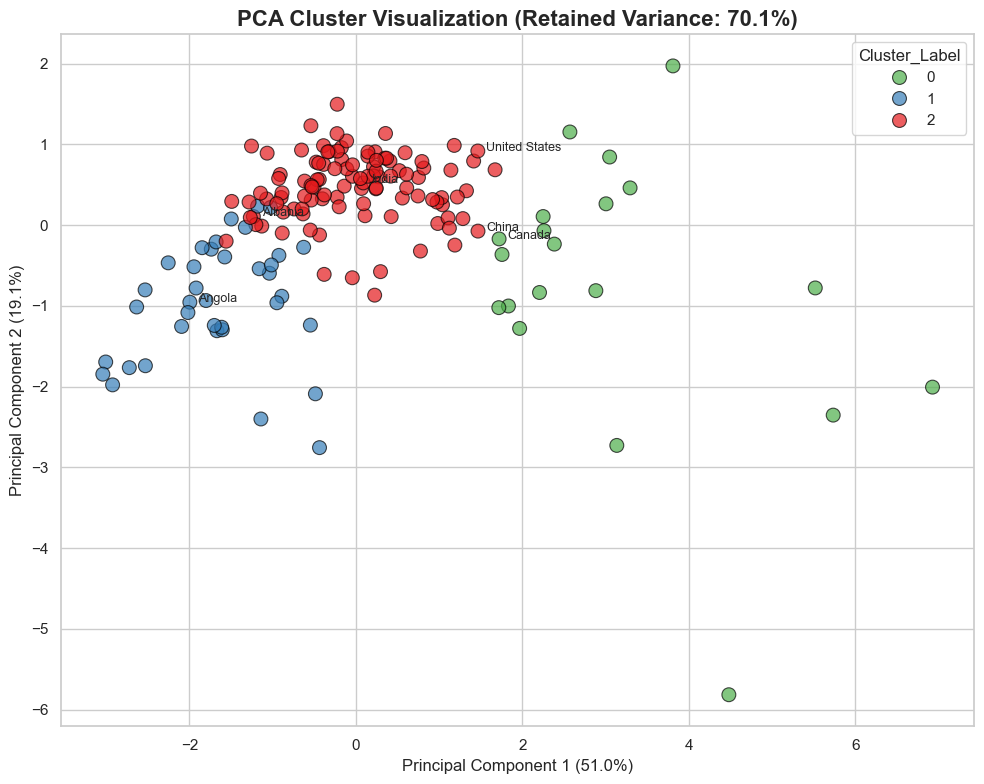

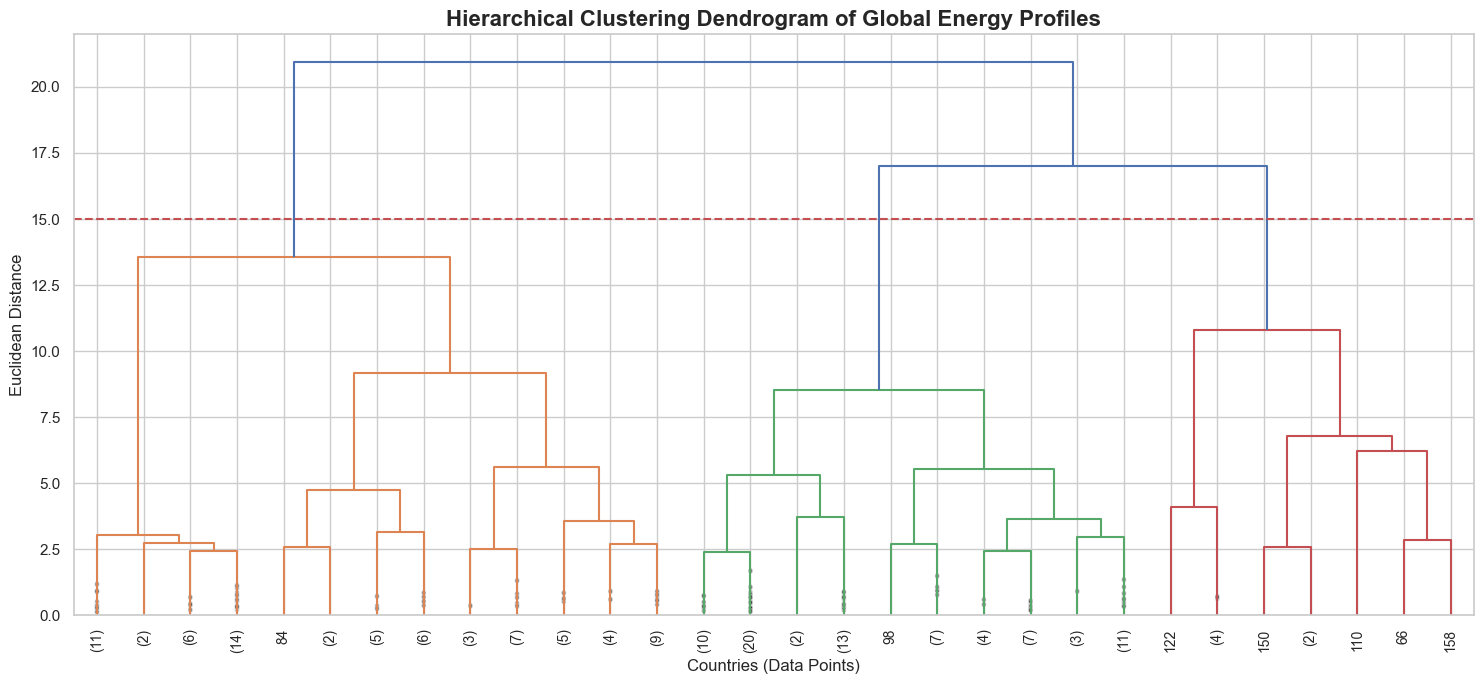

In [7]:
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Part 1: PCA (Principal Component Analysis)
# ==========================================
# We have 5 dimensions (features). We use PCA to compress them into 2 main dimensions
# so we can visualize the clusters on a standard 2D scatter plot.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Add the 2D coordinates back to our dataframe
df_clustering_2021['PCA_Component_1'] = X_pca[:, 0]
df_clustering_2021['PCA_Component_2'] = X_pca[:, 1]

# Calculate how much original information (variance) is kept by these 2 new components
explained_variance = pca.explained_variance_ratio_
total_variance_kept = sum(explained_variance) * 100

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_clustering_2021, 
    x='PCA_Component_1', 
    y='PCA_Component_2', 
    hue='Cluster_Label', 
    palette=['#4daf4a', '#377eb8', '#e41a1c'], # Green, Blue, Red
    s=100, 
    alpha=0.7, 
    edgecolor='black'
)

plt.title(f'PCA Cluster Visualization (Retained Variance: {total_variance_kept:.1f}%)', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}%)', fontsize=12)

# Optional: Add a few country names as text labels to make the plot interesting
sample_countries = ['Canada', 'Angola', 'Albania', 'United States', 'China', 'India']
for idx, row in df_clustering_2021.iterrows():
    if row['Entity'] in sample_countries:
        plt.text(row['PCA_Component_1'] + 0.1, row['PCA_Component_2'], row['Entity'], fontsize=9)

plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# Part 2: Hierarchical Clustering Dendrogram
# ==========================================
# This creates a tree-like diagram to show how countries are grouped together 
# based on their mathematical distances, validating our choice of K=3.

plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram of Global Energy Profiles', fontsize=16, fontweight='bold')
plt.xlabel('Countries (Data Points)', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)

# Using the 'ward' method which minimizes the variance within the clusters
dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward'),
    truncate_mode='lastp',  # Show only the last p merged clusters for clarity
    p=30,                   # Show 30 leaf nodes
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

# Draw a horizontal line to show where we conceptually "cut" the tree to get 3 clusters
plt.axhline(y=15, color='r', linestyle='--') 
plt.tight_layout()
plt.show()

## 5.5 Advanced Structural Validation: 3D PCA Spatial Projection

To rigorously validate the mathematical boundaries established by the K-Means algorithm, a three-dimensional Principal Component Analysis (PCA) projection is implemented. While standard 2D PCA captures primary variances, compressing a high-dimensional feature space into a flat plane often distorts spatial proximity. Generating a 3D interactive geometric space preserves a higher percentage of the original multidimensional structure. This allows for a precise geometric evaluation of cluster separation and internal cohesion, enabling researchers to rotate and inspect the classification boundaries from multiple vector angles.

In [14]:
# Execute 3D PCA
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df_clustering_2021['PCA_1'] = X_pca_3d[:, 0]
df_clustering_2021['PCA_2'] = X_pca_3d[:, 1]
df_clustering_2021['PCA_3'] = X_pca_3d[:, 2]

retained_variance_3d = sum(pca_3d.explained_variance_ratio_) * 100

# Create Interactive 3D Scatter Plot
fig_3d = px.scatter_3d(
    df_clustering_2021,
    x='PCA_1',
    y='PCA_2',
    z='PCA_3',
    color='Cluster_Name',
    hover_name='Entity',
    color_discrete_map={
        'Energy-Hungry Giants (Cluster 0)': '#e41a1c',
        'The Forced Green (Cluster 1)': '#4daf4a',
        'Transitioning Majority (Cluster 2)': '#377eb8'
    },
    title=f"3D PCA Spatial Projection (Retained Variance: {retained_variance_3d:.1f}%)",
    opacity=0.8
)

fig_3d.update_layout(
    title=dict(font=dict(size=18), x=0.5),
    scene=dict(
        xaxis_title='PC 1',
        yaxis_title='PC 2',
        zaxis_title='PC 3'
    ),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig_3d.show()

## 5.6 Cluster Profiling: Normalized Radar Chart Analysis

To synthesize the defining characteristics of the three K-Means clusters, a comparative Radar Chart (Spider Plot) is constructed. Because the selected features possess disparate units and scales (e.g., percentages vs. per capita metric tonnes), the cluster centroids are first normalized using `MinMaxScaler`. This transforms all values to a standardized 0-to-1 scale, ensuring that each axis is proportionally represented. The resulting overlaid polygons visually quantify the macro-economic "footprint" of each cluster, allowing for an immediate comparative assessment of their structural strengths and vulnerabilities across the five primary energy indicators.

In [25]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

# Step 1: Calculate the mean profile for each cluster
radar_features = ['Energy_Intensity', 'CO2_Intensity', 'CO2_Per_Capita', 'Electricity_Access', 'Renewable_Elec_Share']
df_radar = df_clustering_2021.groupby('Cluster_Name')[radar_features].mean().reset_index()

# Step 2: Normalize the features to a 0-1 scale so they fit perfectly on the same radar axes
scaler_radar = MinMaxScaler()
df_radar[radar_features] = scaler_radar.fit_transform(df_radar[radar_features])

# Step 3: Plot the interactive Radar Chart
fig_radar = go.Figure()

colors = {
    'Energy-Hungry Giants (Cluster 0)': '#e41a1c',
    'The Forced Green (Cluster 1)': '#4daf4a',
    'Transitioning Majority (Cluster 2)': '#377eb8'
}

for index, row in df_radar.iterrows():
    cluster = row['Cluster_Name']
    # Append the first value to the end to close the radar polygon
    values = row[radar_features].values.tolist()
    values.append(values[0])
    
    categories = radar_features.copy()
    categories.append(categories[0])
    
    fig_radar.add_trace(go.Scatterpolar(
        r=values,
        theta=categories,
        fill='toself',
        name=cluster,
        line_color=colors[cluster],
        opacity=0.6
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], showticklabels=False)
    ),
    showlegend=True,
    title=dict(text="Standardized Profiles of Global Energy Archetypes", font=dict(size=18), x=0.5),
    legend=dict(yanchor="top", y=1.1, xanchor="center", x=0.5, orientation="h")
)

fig_radar.show()

## 6. Time (Longitudinal) Analysis: Historical Trajectories (2000-2022)

While the initial clustering provided a **cross-sectional "snapshot"** of global energy profiles in 2021, it is essential to understand how these clusters evolved over time. In this section, we propagate the 2021 cluster labels back to our comprehensive **historical panel dataset (2000-2022)**. 

By visualizing these longitudinal trajectories through time-series line plots, we aim to address the following key questions:
* **Cluster 0 (Energy-Hungry Giants):** Have their carbon emissions remained stubbornly high, or is there evidence of a downward convergence?
* **Cluster 1 (The Forced Green):** Have these nations consistently maintained a high renewable share, or has there been a regression in their green energy infrastructure over the past two decades?

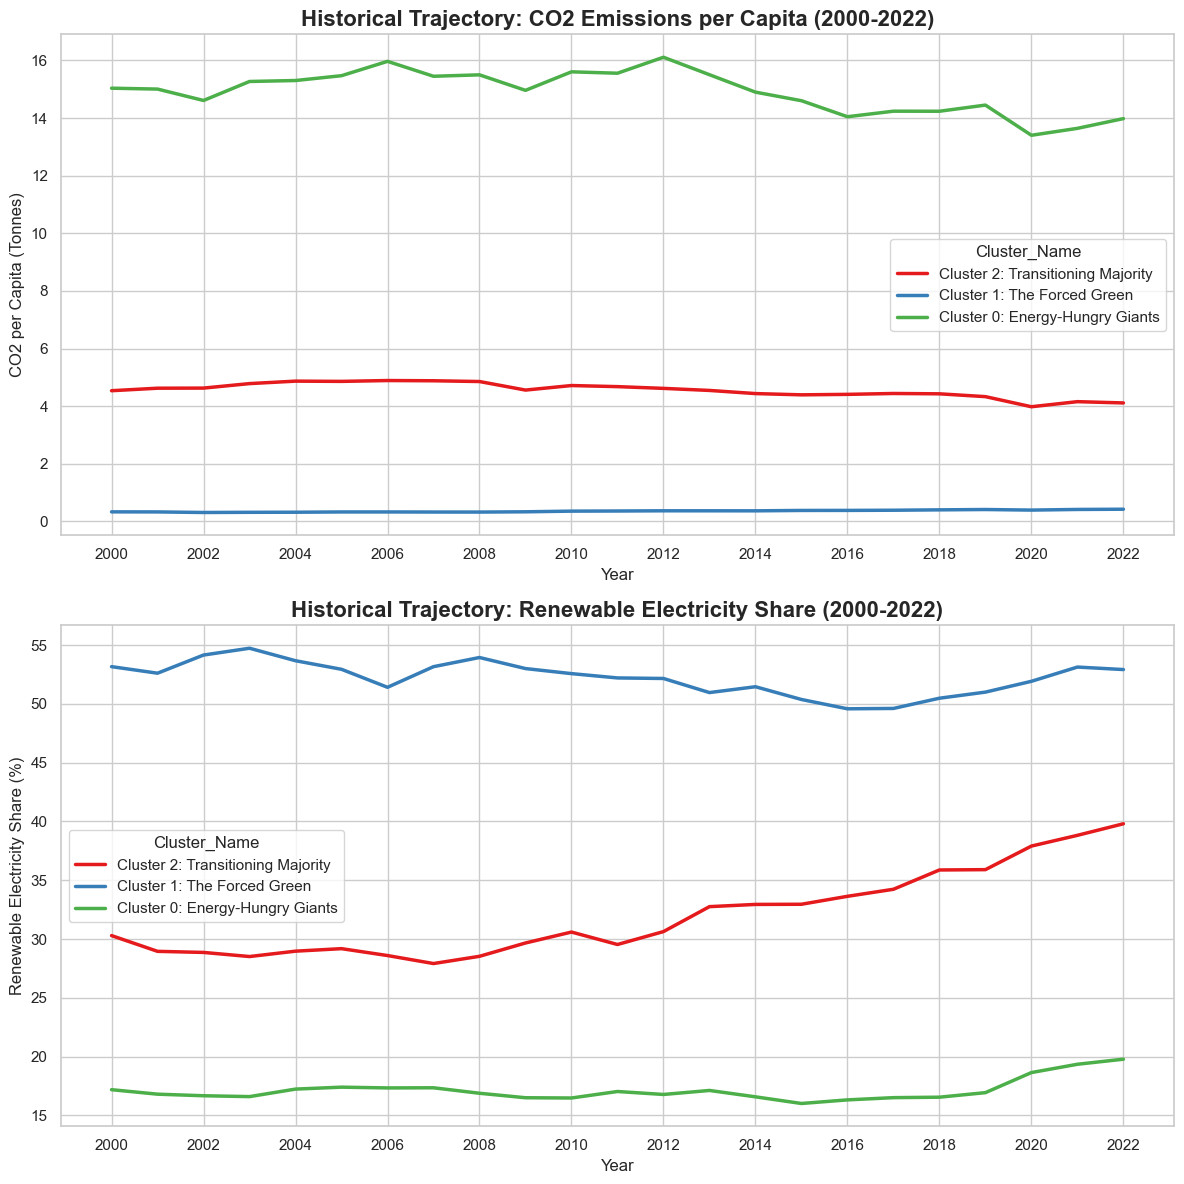

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Step 1: Prepare Historical Data with Cluster Labels
# ==========================================
# First, rename columns in our full historical dataset to match the clean names
df_historical_cleaned = df_final.rename(columns={
    'Energy consumption per dollar': 'Energy_Intensity',
    'Annual CO₂ emissions per GDP (kg per international-$)': 'CO2_Intensity',
    'CO₂ emissions per capita': 'CO2_Per_Capita',
    'Share of the population with access to electricity': 'Electricity_Access',
    'Renewables_y': 'Renewable_Elec_Share'
})

# Extract just the Country Code and its Cluster Label from our 2021 analysis
cluster_mapping = df_clustering_2021[['Code', 'Cluster_Label']]

# Merge the labels back into the 20-year historical dataset
# Using 'inner' join ensures we only keep the 164 countries we analyzed
df_historical_clusters = pd.merge(df_historical_cleaned, cluster_mapping, on='Code', how='inner')

# Map cluster numbers to descriptive names for better plot legends
cluster_names = {
    0: 'Cluster 0: Energy-Hungry Giants',
    1: 'Cluster 1: The Forced Green',
    2: 'Cluster 2: Transitioning Majority'
}
df_historical_clusters['Cluster_Name'] = df_historical_clusters['Cluster_Label'].map(cluster_names)

# ==========================================
# Step 2: Plot Historical Trajectories (Time Series)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Plot 1: CO2 Emissions per Capita over time
sns.lineplot(
    data=df_historical_clusters, 
    x='Year', 
    y='CO2_Per_Capita', 
    hue='Cluster_Name', 
    estimator='mean', # Calculate the average for the cluster per year
    errorbar=None,    # Remove confidence interval shading for cleaner look
    linewidth=2.5,
    ax=axes[0],
    palette='Set1'
)
axes[0].set_title('Historical Trajectory: CO2 Emissions per Capita (2000-2022)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('CO2 per Capita (Tonnes)', fontsize=12)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_xticks(range(2000, 2023, 2))

# Plot 2: Renewable Electricity Share over time
sns.lineplot(
    data=df_historical_clusters, 
    x='Year', 
    y='Renewable_Elec_Share', 
    hue='Cluster_Name', 
    estimator='mean',
    errorbar=None,
    linewidth=2.5,
    ax=axes[1],
    palette='Set1'
)
axes[1].set_title('Historical Trajectory: Renewable Electricity Share (2000-2022)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Renewable Electricity Share (%)', fontsize=12)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_xticks(range(2000, 2023, 2))

plt.tight_layout()
plt.show()

## 7. Supervised Learning: Random Forest Attribution

A Random Forest Regressor is implemented to quantify the relative impact of socio-economic and technical factors on per capita CO2 emissions. To ensure the integrity of the model, `CO2_Intensity` is intentionally excluded from the feature set. This prevents **Data Leakage**, as both the feature and the target variable share a common mathematical numerator (total emissions), which would otherwise lead to an overfitted model and obscure the true influence of other drivers. By focusing on Energy Intensity, Electricity Access, and Renewable Share, the model is forced to identify the underlying structural levers of decarbonization.

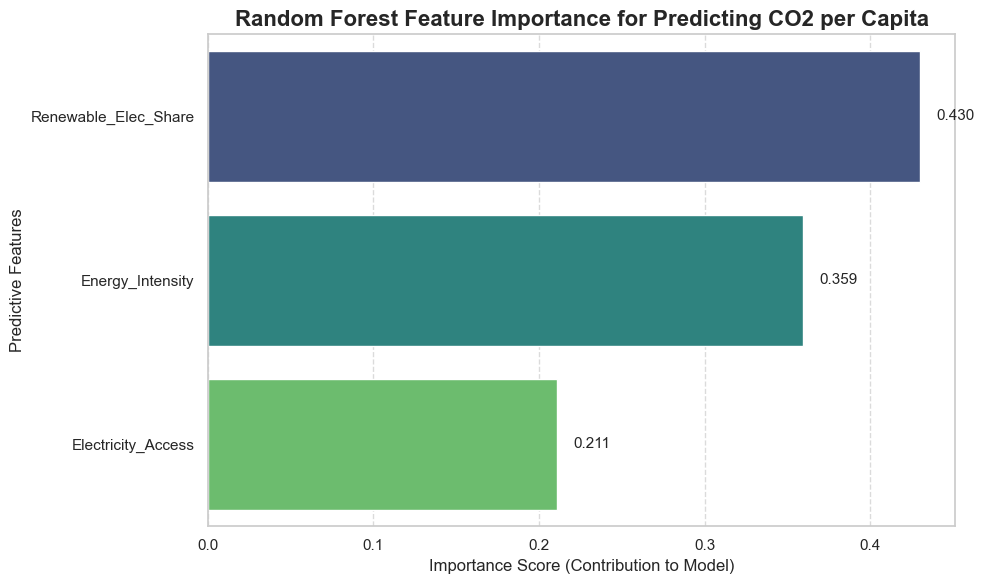

In [21]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Part 1: Prepare Data for Supervised Learning
# ==========================================
# Target variable (Y): What we want to predict (CO2 per Capita)
y_rf = df_clustering_2021['CO2_Per_Capita']

# Features (X): The factors we think influence CO2 emissions
# Note: We exclude CO2_Intensity here to avoid data leakage, 
# as it is mathematically derived from similar base variables.
features_rf = ['Energy_Intensity', 'Electricity_Access', 'Renewable_Elec_Share']
X_rf = df_clustering_2021[features_rf]

# ==========================================
# Part 2: Train the Random Forest Regressor
# ==========================================
# Initialize the Random Forest model with 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train (fit) the model
rf_model.fit(X_rf, y_rf)

# ==========================================
# Part 3: Extract and Plot Feature Importance
# ==========================================
# Get the importance scores calculated by the Random Forest
importances = rf_model.feature_importances_

# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'Feature': features_rf,
    'Importance_Score': importances
})

# Sort the features from most important to least important
importance_df = importance_df.sort_values(by='Importance_Score', ascending=False)

# Plotting the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df, 
    x='Importance_Score', 
    y='Feature', 
    palette='viridis'
)

plt.title('Random Forest Feature Importance for Predicting CO2 per Capita', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Contribution to Model)', fontsize=12)
plt.ylabel('Predictive Features', fontsize=12)

# Add the exact scores as text on the bars for clarity
for index, value in enumerate(importance_df['Importance_Score']):
    plt.text(value + 0.01, index, f'{value:.3f}', va='center', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Model Robustness Check: Gaussian Mixture Model (GMM) Cross-Validation

To evaluate the structural stability of the K-Means results, a Gaussian Mixture Model (GMM) is implemented as a cross-validation measure. Unlike K-Means, which relies on Euclidean distance and assumes spherical cluster shapes, GMM utilizes a probabilistic approach that accounts for clusters with varying latent distributions and orientations. By calculating the Adjusted Rand Index (ARI), the level of agreement between the distance-based and density-based clustering methods is quantified. This stage is designed to determine if the country groupings are sensitive to the underlying mathematical assumptions of the clustering algorithm or if they represent persistent patterns in the global energy data.

In [22]:
from sklearn.mixture import GaussianMixture

# ==========================================
# Gaussian Mixture Model (GMM) Clustering
# ==========================================
# We use K=3 again so we can compare it directly with K-Means results

# Initialize GMM
gmm = GaussianMixture(n_components=3, random_state=42, n_init=10)

# Fit and predict the clusters based on probability distributions
df_clustering_2021['GMM_Cluster'] = gmm.fit_predict(X_scaled)

# Let's compare how similar the GMM results are to K-Means
from sklearn.metrics import adjusted_rand_score

# Calculate the Adjusted Rand Index (ARI)
# ARI measures the similarity between two clustering algorithms (1.0 is identical)
ari_score = adjusted_rand_score(df_clustering_2021['Cluster_Label'], df_clustering_2021['GMM_Cluster'])

print(f"======================================================")
print(f"ALGORITHM COMPARISON: K-Means vs. GMM")
print(f"======================================================")
print(f"Adjusted Rand Index (ARI) Score: {ari_score:.4f}")

if ari_score > 0.7:
    print("Conclusion: The GMM highly validates our K-Means clustering. The structure is robust.")
else:
    print("Conclusion: GMM found a significantly different distribution, warranting further investigation.")

ALGORITHM COMPARISON: K-Means vs. GMM
Adjusted Rand Index (ARI) Score: 0.3444
Conclusion: GMM found a significantly different distribution, warranting further investigation.


## 9. Explainable AI (XAI): Model Deconstruction via SHAP Values

To transition from global feature importance to a more granular, local explanation of the model's decision-making process, the SHAP (SHapley Additive exPlanations) framework is applied. While the preceding Random Forest importance scores rank the overall contribution of features, SHAP values—rooted in cooperative game theory—quantify how each specific variable pushes the prediction for an individual nation away from the global mean. This diagnostic approach allows for the deconstruction of non-linear relationships between electrification, energy intensity, and carbon output. The resulting summary plot visualizes the distribution of these impacts across the entire 2021 dataset, mapping original feature values (color-coded) to their corresponding directional influence on CO2 per capita (x-axis).

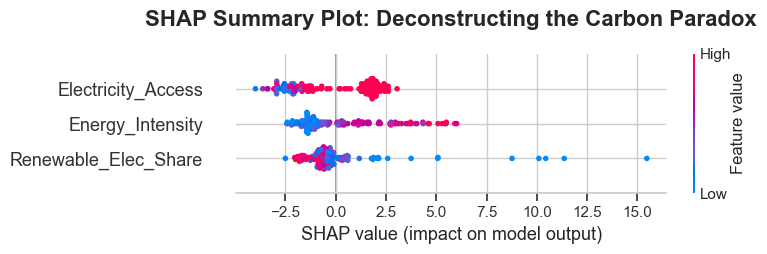

In [23]:
import shap
import matplotlib.pyplot as plt

# ==========================================
# Explain the Random Forest Model with SHAP
# ==========================================
# Initialize the SHAP explainer using our previously trained Random Forest model (rf_model)
# Note: We are using X_rf which contains ['Energy_Intensity', 'Electricity_Access', 'Renewable_Elec_Share']
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for all countries in our dataset
shap_values = explainer.shap_values(X_rf)

# ==========================================
# Plot the SHAP Summary Plot
# ==========================================
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Deconstructing the Carbon Paradox", fontsize=16, fontweight='bold', pad=20)

# Generate the summary plot. 
# Each dot represents a country. 
# Color represents the original feature value (Red = High, Blue = Low).
# X-axis represents the impact on CO2 per capita (Positive = Increases CO2, Negative = Decreases CO2).
shap.summary_plot(shap_values, X_rf, show=False)

plt.tight_layout()
plt.show()

## 10. Deep Learning Integration: Temporal Forecasting via LSTM

To move beyond cross-sectional classification and capture the historical inertia of carbon emissions, a Long Short-Term Memory (LSTM) neural network is introduced. Unlike traditional regression models, LSTMs possess recurrent structural gates designed to retain long-term dependencies within sequential data. 

### 10.1 Panel Data Preprocessing and Tensor Generation
Preparing multi-national panel data for an LSTM architecture requires transforming standard 2D dataframes into 3D tensors `(Samples, Sequence Length, Features)`. 
* **Sliding Window Mechanism:** A sequence length of 5 years is defined. The model uses the past 5 years of a nation's energy metrics to predict the 6th year's carbon output.
* **Spatial Isolation:** To prevent temporal cross-contamination, the sliding window function iterates strictly within individual country codes. The timeline of one nation is mathematically isolated from another.
* **Normalization:** All features are scaled using `MinMaxScaler` to ensure the gradient descent process converges efficiently without being dominated by features with massive absolute values (e.g., total energy intensity).

In [28]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ==========================================
# Step 1: Filter and Clean Data for LSTM
# ==========================================
# 💡 FIX: Use df_historical instead of df_final because df_historical has the renamed columns!
lstm_features = ['Energy_Intensity', 'Electricity_Access', 'Renewable_Elec_Share', 'CO2_Per_Capita']

# Sort strictly by Country and Year to maintain chronological order
df_lstm = df_historical[['Code', 'Year'] + lstm_features].sort_values(by=['Code', 'Year']).dropna()

# ==========================================
# Step 2: Global Feature Scaling
# ==========================================
# Neural networks require normalized inputs to converge efficiently
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler() # Separate scaler for the target variable for inverse-transforming later

df_lstm_scaled = df_lstm.copy()
df_lstm_scaled[lstm_features] = scaler_X.fit_transform(df_lstm[lstm_features])

# Fit scaler_y exclusively on the target for future prediction decoding
scaler_y.fit(df_lstm[['CO2_Per_Capita']])

# ==========================================
# Step 3: Sequential Sliding Window Generation
# ==========================================
SEQ_LENGTH = 5  # Use past 5 years to predict the next year

def create_sequences(df, seq_length):
    xs = []
    ys = []
    
    # Iterate through each country separately to avoid cross-country data leakage
    for code in df['Code'].unique():
        country_data = df[df['Code'] == code][lstm_features].values
        
        # Only process if the country has enough historical data
        if len(country_data) > seq_length:
            for i in range(len(country_data) - seq_length):
                x = country_data[i:(i + seq_length)]
                # Target is the CO2_Per_Capita (index 3) of the NEXT year
                y = country_data[i + seq_length][3] 
                xs.append(x)
                ys.append(y)
                
    return np.array(xs), np.array(ys)

X_seq, y_seq = create_sequences(df_lstm_scaled, SEQ_LENGTH)

# ==========================================
# Step 4: Convert to PyTorch Tensors
# ==========================================
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.float32).view(-1, 1)

print("Tensor Generation Complete!")
print(f"Total temporal sequences created: {len(X_tensor)}")
print(f"Input Tensor Shape: {X_tensor.shape} -> (Total Samples, Sequence Length, Features)")
print(f"Target Tensor Shape: {y_tensor.shape}")

Tensor Generation Complete!
Total temporal sequences created: 2909
Input Tensor Shape: torch.Size([2909, 5, 4]) -> (Total Samples, Sequence Length, Features)
Target Tensor Shape: torch.Size([2909, 1])


### 10.2 LSTM Network Architecture and Model Training

With the multidimensional tensors prepared, a custom Long Short-Term Memory (LSTM) neural network is initialized using PyTorch. The architecture consists of stacked LSTM layers designed to extract temporal patterns from the 5-year historical windows, followed by fully connected linear layers to map these extracted features to a continuous target variable (`CO2_Per_Capita`). 

To ensure generalizability, the dataset is divided into an 80/20 train-test split. The training process utilizes the Adam optimizer and Mean Squared Error (MSE) as the loss function. A dropout regularization technique is incorporated within the LSTM layers to mitigate overfitting. The progression of both training and validation losses is recorded across 100 epochs to empirically verify the model's convergence and stability.

Starting LSTM Training...
Epoch [20/100], Train Loss: 0.000233, Validation Loss: 0.000179
Epoch [40/100], Train Loss: 0.000214, Validation Loss: 0.000164
Epoch [60/100], Train Loss: 0.000185, Validation Loss: 0.000145
Epoch [80/100], Train Loss: 0.000154, Validation Loss: 0.000130
Epoch [100/100], Train Loss: 0.000142, Validation Loss: 0.000104
Training Completed!


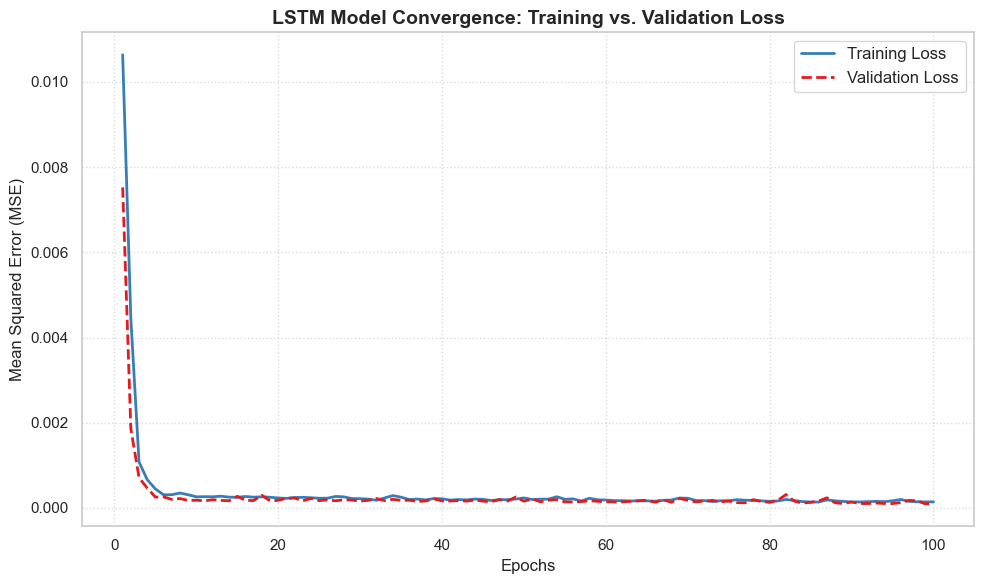

In [29]:
import torch.optim as optim
import torch.utils.data as data
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# Step 1: Train-Test Split & Data Loaders
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

train_dataset = data.TensorDataset(X_train, y_train)
test_dataset = data.TensorDataset(X_test, y_test)

# Use DataLoader for batch processing
batch_size = 64
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# Step 2: Define the PyTorch LSTM Architecture
# ==========================================
class CarbonLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(CarbonLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer with dropout for regularization
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        
        # Fully connected layers for the final prediction
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)
        
    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Extract the output of the last time step
        out = out[:, -1, :]
        
        # Pass through fully connected layers
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Initialize model parameters
input_size = 4  # Number of features (Energy_Intensity, Elec_Access, Renew_Share, CO2)
hidden_size = 64
num_layers = 2
output_size = 1 # Predicting CO2_Per_Capita

model = CarbonLSTM(input_size, hidden_size, num_layers, output_size)

# ==========================================
# Step 3: Training Loop Setup
# ==========================================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

train_losses = []
val_losses = []

print("Starting LSTM Training...")

for epoch in range(epochs):
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    train_losses.append(np.mean(batch_losses))
    
    # Validation Phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
        val_losses.append(val_loss.item())
        
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.6f}, Validation Loss: {val_losses[-1]:.6f}')

print("Training Completed!")

# ==========================================
# Step 4: Plot the Loss Curve
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', color='#377eb8', linewidth=2)
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', color='#e41a1c', linewidth=2, linestyle='--')
plt.title('LSTM Model Convergence: Training vs. Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### 10.3 Autoregressive Forecasting: Projecting the Carbon Paradox to 2030

With the LSTM model successfully trained and validated, the final analytical phase involves forecasting per capita CO2 emissions up to the year 2030. This projection utilizes a **"Business-as-Usual" (BAU) scenario**. Under this framework, the structural energy parameters (Energy Intensity, Electricity Access, and Renewable Share) are held constant at their 2022 levels, while the LSTM's recurrent memory cells autoregressively project the trajectory of carbon emissions based on historical momentum. 

An iterative sliding window approach is employed: the model predicts the emissions for $T+1$, appends this prediction to the sequence, drops the oldest temporal record, and predicts $T+2$. The resulting forecasted tensors are subsequently inverse-transformed to their original scale (tonnes of CO2) and aggregated by the previously established K-Means clusters. The final visualization provides a continuous, interactive trajectory from historical actuals (2000-2022) to deep-learning-driven forecasts (2023-2030).

In [33]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import torch

# ==========================================
# Step 1: Autoregressive Forecast (2023-2030)
# ==========================================
model.eval()
future_years = list(range(2023, 2031))
forecast_results = []

# Get the cluster labels from our 2021 cross-section to map them later
cluster_map = df_clustering_2021.set_index('Code')['Cluster_Name'].to_dict()

with torch.no_grad():
    for code in df_lstm['Code'].unique():
        if code not in cluster_map:
            continue # Skip if we don't have a cluster label for this country
            
        country_data = df_lstm_scaled[df_lstm_scaled['Code'] == code][lstm_features].values
        
        if len(country_data) >= SEQ_LENGTH:
            # Get the last available 5-year window (2018-2022)
            current_seq = country_data[-SEQ_LENGTH:].copy()
            
            for year in future_years:
                # Prepare tensor for prediction
                seq_tensor = torch.tensor(current_seq, dtype=torch.float32).unsqueeze(0)
                pred_co2_scaled = model(seq_tensor).item()
                
                # Record the prediction
                forecast_results.append({
                    'Code': code,
                    'Year': year,
                    'Cluster_Name': cluster_map[code],
                    'CO2_Per_Capita_Scaled': pred_co2_scaled
                })
                
                # Update the sequence for the next year's prediction (Business-as-Usual assumption)
                # Keep Energy_Intensity, Elec_Access, Renew_Share constant at the last known value
                new_step = current_seq[-1].copy()
                new_step[3] = pred_co2_scaled # Update the CO2 feature with the new prediction
                
                # Slide the window
                current_seq = np.vstack((current_seq[1:], new_step))

# ==========================================
# Step 2: Inverse Transform and Aggregate Data
# ==========================================
df_forecast = pd.DataFrame(forecast_results)

# Inverse transform the scaled predictions back to actual CO2 tonnes
df_forecast['CO2_Per_Capita'] = scaler_y.inverse_transform(df_forecast[['CO2_Per_Capita_Scaled']])

# Calculate mean projections per cluster
df_proj_cluster = df_forecast.groupby(['Year', 'Cluster_Name'])['CO2_Per_Capita'].mean().reset_index()

# FIX HERE: Map the 2021 cluster labels back to the historical LSTM dataset
df_lstm_mapped = df_lstm.copy()
df_lstm_mapped['Cluster_Name'] = df_lstm_mapped['Code'].map(cluster_map)
df_lstm_mapped = df_lstm_mapped.dropna(subset=['Cluster_Name']) # Remove any unmapped regions

# Calculate historical means per cluster for the plot
df_hist_cluster = df_lstm_mapped.groupby(['Year', 'Cluster_Name'])['CO2_Per_Capita'].mean().reset_index()

# ==========================================
# Step 3: Interactive Plotly Fan Chart
# ==========================================
fig_forecast = go.Figure()

colors = {
    'Energy-Hungry Giants (Cluster 0)': '#e41a1c',
    'The Forced Green (Cluster 1)': '#4daf4a',
    'Transitioning Majority (Cluster 2)': '#377eb8'
}

for cluster in colors.keys():
    # 1. Plot Historical Data (Solid Lines)
    hist_data = df_hist_cluster[df_hist_cluster['Cluster_Name'] == cluster]
    fig_forecast.add_trace(go.Scatter(
        x=hist_data['Year'], y=hist_data['CO2_Per_Capita'],
        mode='lines', name=f'{cluster} (Historical)',
        line=dict(color=colors[cluster], width=3)
    ))
    
    # 2. Plot Forecast Data (Dashed Lines)
    # To connect the lines seamlessly, we need the 2022 data point from the historical data
    last_hist_point = hist_data[hist_data['Year'] == 2022]
    proj_data = df_proj_cluster[df_proj_cluster['Cluster_Name'] == cluster]
    combined_proj = pd.concat([last_hist_point, proj_data])
    
    fig_forecast.add_trace(go.Scatter(
        x=combined_proj['Year'], y=combined_proj['CO2_Per_Capita'],
        mode='lines', name=f'{cluster} (LSTM Forecast)',
        line=dict(color=colors[cluster], width=3, dash='dash')
    ))

# Add a vertical line to indicate the start of the forecast horizon
fig_forecast.add_vline(x=2022, line_width=2, line_dash="dot", line_color="black")

fig_forecast.add_annotation(
    x=2022.2,
    y=1.05,
    yref="paper",
    text="AI Forecast Horizon (2030) ➔", 
    showarrow=False, 
    font=dict(size=12, color="black", weight="bold"),
    xanchor="left"
)

fig_forecast.update_layout(
    title=dict(text="Projecting the Carbon Paradox: LSTM Neural Network Forecast to 2030", font=dict(size=18), x=0.5),
    xaxis_title="Year",
    yaxis_title="CO2 Emissions per Capita (Tonnes)",
    hovermode="x unified",
  
    legend=dict(
        yanchor="top", 
        y=1, 
        xanchor="left", 
        x=1.02,
        bgcolor="rgba(255, 255, 255, 0.8)"
    ),
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray'),
    margin=dict(r=150)
)

fig_forecast.show()